# Access Control System


Use of machine learning to detect unauthorized RFID card entries in an Access Control System (ACS). Synthetic datasets were generated based on real dormitory entry patterns from online sources, supplemented using ChatGPT 4. Two datasets are used: a training set and a control (attack) set.

Each record contains 5 features obtainable from an RFID reader and a ToF (Time-of-Flight) sensor that are also suitable for machine learning algorithms:

day_of_week
time_of_day_seconds
rfid_hold_duration_ms
tof_sample_interval_ms
tof_distance_mm_array


## Testing

Testing is performed on all records in the dataset using the chosen algorithm. Results are recorded and evaluated for both the training and testing datasets. This step is important because the algorithm must generalize — it must not only predict the data it was trained on but also data it has never seen before. There are many metrics we can measure; for the purposes of this project I focus on two that define algorithm quality:
1. False Rejection Rate — FRR
2. False Acceptance Rate — FAR


## Dataset Loading

In this step we simply import libraries and load the dataset.


In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import EllipticEnvelope
from sklearn.neural_network import MLPRegressor


In [2]:
test = pd.read_csv("data/rfid_reader_tof_owner_dataset_testing_attack_v2.csv")
df = pd.read_csv("data/rfid_reader_tof_owner_dataset_realistic_v3.csv")
df.head()


,day_of_week,time_of_day_seconds,rfid_hold_duration_ms,tof_sample_interval_ms,tof_distance_mm_array
0,3,58542,1850,50,"[520, 483, 451, 407, 385, 348, 319, 289, 261, ..."
1,5,71091,2269,50,"[463, 431, 407, 386, 356, 327, 312, 292, 266, ..."
2,0,25421,2164,50,"[476, 454, 415, 394, 371, 342, 316, 298, 279, ..."
3,0,63537,2206,50,"[536, 510, 477, 451, 422, 389, 370, 348, 321, ..."
4,1,28022,2162,50,"[415, 397, 376, 356, 332, 308, 290, 271, 253, ..."


## Data Processing

Using this synthetic dataset we test a PoC machine learning model. The approach is to incrementally add features to the algorithm and observe the effect on performance.


### Data Validation

An important step is to check data health and prepare it for the algorithms. The code below checks column types and completeness. It is essential that all rows have values. Since the dataset is partly synthetic and supplemented by ChatGPT, we expect full coverage — which was confirmed.


In [3]:
print("=== Dataset summary ===")
print(f"Records: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"\nColumn types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")


=== Základné informácie o datasete ===
Počet záznamov: 125
Počet stĺpcov: 5

Typy stĺpcov:
day_of_week               int64
time_of_day_seconds       int64
rfid_hold_duration_ms     int64
tof_sample_interval_ms    int64
tof_distance_mm_array       str
dtype: object

Chýbajúce hodnoty:
day_of_week               0
time_of_day_seconds       0
rfid_hold_duration_ms     0
tof_sample_interval_ms    0
tof_distance_mm_array     0
dtype: int64


### Feature Engineering

The raw data is not ideal for machine learning algorithms, especially columns like *day_of_week* or *time_of_day_seconds*. These are easy to read for humans but can confuse algorithms — for example 00:00 is the opposite of 23:59, etc.

To address this:
- time and day of week are encoded cyclically
- numerical features are derived from the ToF array
- raw columns are kept but the model works primarily with the derived variables


In [4]:
def prepare_features(frame):
    frame = frame.copy()

    # cyclical time encoding
    frame['time_sin'] = np.sin(2 * np.pi * frame['time_of_day_seconds'] / 86400)
    frame['time_cos'] = np.cos(2 * np.pi * frame['time_of_day_seconds'] / 86400)

    # cyclical day encoding
    frame['day_sin'] = np.sin(2 * np.pi * frame['day_of_week'] / 7)
    frame['day_cos'] = np.cos(2 * np.pi * frame['day_of_week'] / 7)

    # simple weekend flag
    frame['is_weekend'] = frame['day_of_week'].isin([5, 6]).astype(int)

    # parse ToF array
    frame['tof_array'] = frame['tof_distance_mm_array'].apply(json.loads)

    # ToF derived features
    frame['tof_len'] = frame['tof_array'].apply(len)
    frame['tof_start'] = frame['tof_array'].apply(lambda x: x[0])
    frame['tof_end'] = frame['tof_array'].apply(lambda x: x[-1])
    frame['tof_min'] = frame['tof_array'].apply(min)
    frame['tof_max'] = frame['tof_array'].apply(max)
    frame['tof_mean'] = frame['tof_array'].apply(np.mean)
    frame['tof_std'] = frame['tof_array'].apply(np.std)
    frame['tof_range'] = frame['tof_max'] - frame['tof_min']
    frame['tof_approach_distance'] = frame['tof_start'] - frame['tof_end']
    frame['tof_approach_speed'] = frame['tof_approach_distance'] / (
        frame['tof_len'] * frame['tof_sample_interval_ms']
    )

    return frame

df_features = prepare_features(df)
test_features = prepare_features(test)

train_normal, test_normal = train_test_split(
    df_features,
    test_size=0.3,
    random_state=42
)

test_attack = test_features.copy()

df_features.head()


,day_of_week,time_of_day_seconds,rfid_hold_duration_ms,tof_sample_interval_ms,tof_distance_mm_array,time_sin,time_cos,day_sin,day_cos,is_weekend,...,tof_len,tof_start,tof_end,tof_min,tof_max,tof_mean,tof_std,tof_range,tof_approach_distance,tof_approach_speed
0,3,58542,1850,50,"[520, 483, 451, 407, 385, 348, 319, 289, 261, ...",-0.898219,-0.439547,0.433884,-0.900969,0,...,32,520,46,44,520,179.218750,145.062214,476,474,0.296250
1,5,71091,2269,50,"[463, 431, 407, 386, 356, 327, 312, 292, 266, ...",-0.897162,0.441702,-0.974928,-0.222521,1,...,40,463,56,52,463,161.725000,122.774588,411,407,0.203500
2,0,25421,2164,50,"[476, 454, 415, 394, 371, 342, 316, 298, 279, ...",0.961642,-0.274309,0.000000,1.000000,0,...,40,476,32,28,476,153.125000,135.578610,448,444,0.222000
3,0,63537,2206,50,"[536, 510, 477, 451, 422, 389, 370, 348, 321, ...",-0.995785,-0.091719,0.000000,1.000000,0,...,39,536,60,54,536,192.820513,145.925846,482,476,0.244103
4,1,28022,2162,50,"[415, 397, 376, 356, 332, 308, 290, 271, 253, ...",0.892913,-0.450228,0.781831,0.623490,0,...,38,415,54,50,415,153.947368,113.341577,365,361,0.190000


### Card Tap Time

This is the first feature the algorithm will learn from. We start by visualizing the data.


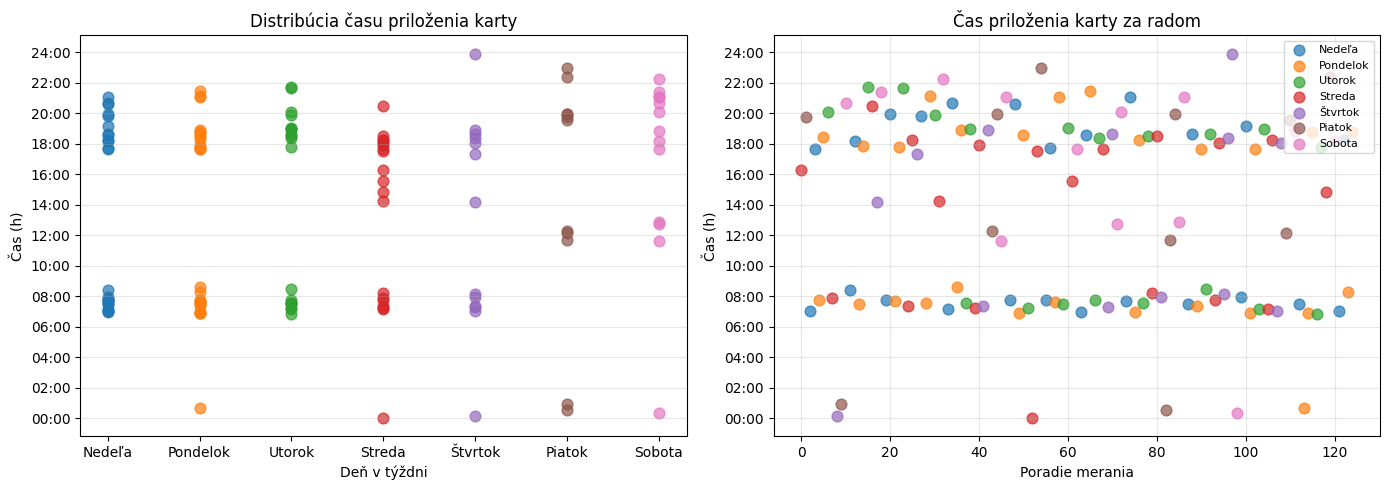

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# First plot — tap time distribution by day
days = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
colors = plt.cm.tab10.colors

for day_idx, day_name in enumerate(days):
    mask = df['day_of_week'] == day_idx
    times = df.loc[mask, 'time_of_day_seconds'] / 3600  # convert to hours
    axes[0].scatter([day_name] * mask.sum(), times, label=day_name, color=colors[day_idx], alpha=0.7, s=60)

axes[0].set_xlabel('Day of week')
axes[0].set_ylabel('Time (h)')
axes[0].set_title('Card tap time distribution')
axes[0].set_yticks(range(0, 25, 2))
axes[0].set_yticklabels([f'{h:02d}:00' for h in range(0, 25, 2)])
axes[0].grid(axis='y', alpha=0.3)

# Second plot — tap times in sequence, coloured by day
for day_idx, day_name in enumerate(days):
    mask = df['day_of_week'] == day_idx
    indices = df.index[mask]
    times = df.loc[mask, 'time_of_day_seconds'] / 3600
    axes[1].scatter(indices, times, label=day_name, color=colors[day_idx], alpha=0.7, s=60)

axes[1].set_xlabel('Measurement index')
axes[1].set_ylabel('Time (h)')
axes[1].set_title('Card tap times in sequence')
axes[1].set_yticks(range(0, 25, 2))
axes[1].set_yticklabels([f'{h:02d}:00' for h in range(0, 25, 2)])
axes[1].legend(loc='upper right', fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


The data shows that the monitored entity taps their card quite regularly, around 08:00 and 18:00 every day, with some variance. There are several ways to detect unauthorized entry in this situation; the most intuitive simple approaches are:

- Rule-based detection — fixed rules such as: entry outside 7:00–9:00 and 17:00–20:00 = suspicious
- Threshold-based detection — if the tap time deviates from normal by more than a limit, flag it

I will use threshold-based detection as the baseline. If machine learning cannot outperform it, there is no logical reason to use it.
For the experiment I use deviation from the median. Results will be recorded for 1-, 2-, and 5-hour offsets.


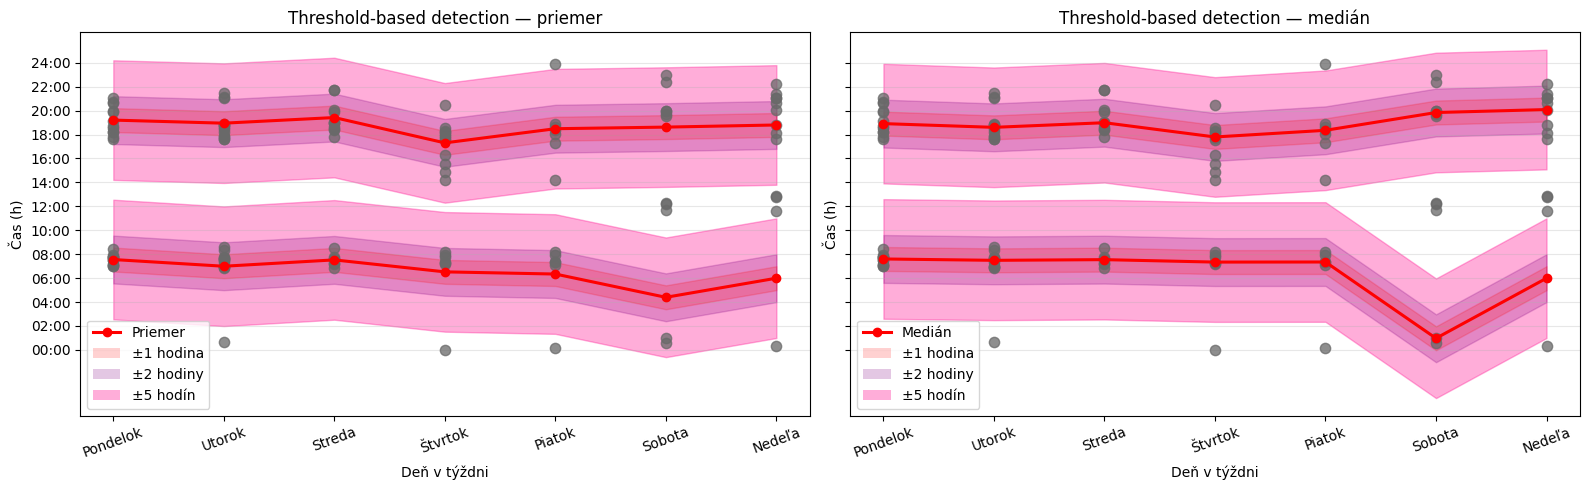

In [6]:
# correct weekday order: 0=Mon ... 6=Sun
day_labels = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
x = np.arange(7)

# data points in uniform colour
point_color = 'dimgray'
line_color = 'red'

# band colours
c_1h = 'red'
c_2h = 'purple'
c_5h = 'deeppink'

def plot_threshold(ax, morning_vals, evening_vals, title, center_label):
    # scatter points
    for day_idx in range(7):
        mask = df['day_of_week'] == day_idx
        times = df.loc[mask, 'time_of_day_seconds'] / 3600
        ax.scatter(
            np.full(mask.sum(), day_idx),
            times,
            color=point_color,
            alpha=0.75,
            s=55,
            zorder=3
        )

    # bands for morning and evening curves
    for vals in [morning_vals, evening_vals]:
        ax.fill_between(x, vals - 5, vals + 5, color=c_5h, alpha=0.35, zorder=0)
        ax.fill_between(x, vals - 2, vals + 2, color=c_2h, alpha=0.22, zorder=1)
        ax.fill_between(x, vals - 1, vals + 1, color=c_1h, alpha=0.18, zorder=2)

    # curves in uniform colour
    ax.plot(x, morning_vals, marker='o', linewidth=2.2, color=line_color, zorder=4)
    ax.plot(x, evening_vals, marker='o', linewidth=2.2, color=line_color, zorder=4)

    ax.set_xticks(x)
    ax.set_xticklabels(day_labels, rotation=20)
    ax.set_xlabel('Day of week')
    ax.set_ylabel('Time (h)')
    ax.set_title(title)
    ax.set_yticks(range(0, 25, 2))
    ax.set_yticklabels([f'{h:02d}:00' for h in range(0, 25, 2)])
    ax.grid(axis='y', alpha=0.3)

    handles = [
        Line2D([0], [0], color=line_color, marker='o', linewidth=2.2, label=center_label),
        Patch(facecolor=c_1h, alpha=0.18, label='±1 hour'),
        Patch(facecolor=c_2h, alpha=0.22, label='±2 hours'),
        Patch(facecolor=c_5h, alpha=0.35, label='±5 hours'),
    ]
    ax.legend(handles=handles)

# mean
morning_mean = (
    df.loc[df['time_of_day_seconds'] < 12 * 3600]
      .groupby('day_of_week')['time_of_day_seconds']
      .mean()
      .reindex(range(7)) / 3600
)

evening_mean = (
    df.loc[df['time_of_day_seconds'] >= 12 * 3600]
      .groupby('day_of_week')['time_of_day_seconds']
      .mean()
      .reindex(range(7)) / 3600
)

# median
morning_median = (
    df.loc[df['time_of_day_seconds'] < 12 * 3600]
      .groupby('day_of_week')['time_of_day_seconds']
      .median()
      .reindex(range(7)) / 3600
)

evening_median = (
    df.loc[df['time_of_day_seconds'] >= 12 * 3600]
      .groupby('day_of_week')['time_of_day_seconds']
      .median()
      .reindex(range(7)) / 3600
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

plot_threshold(axes[0], morning_mean, evening_mean, 'Threshold-based detection — mean', 'Priemer')
plot_threshold(axes[1], morning_median, evening_median, 'Threshold-based detection — median', 'Medián')

plt.tight_layout()
plt.show()


In [7]:
# Threshold-based detection — FAR and FRR evaluation

thresholds = [1, 2, 5]  # hours

# compute morning and evening median from training data
morning_med = (
    train_normal.loc[train_normal['time_of_day_seconds'] < 12 * 3600]
      .groupby('day_of_week')['time_of_day_seconds']
      .median() / 3600
)
evening_med = (
    train_normal.loc[train_normal['time_of_day_seconds'] >= 12 * 3600]
      .groupby('day_of_week')['time_of_day_seconds']
      .median() / 3600
)

def is_anomaly_threshold(row, morning_med, evening_med, threshold_h):
    t = row['time_of_day_seconds'] / 3600
    day = row['day_of_week']
    if t < 12:
        center = morning_med.get(day, np.nan)
    else:
        center = evening_med.get(day, np.nan)
    if np.isnan(center):
        return True
    return abs(t - center) > threshold_h

results = []

for thr in thresholds:
    # === TEST NORMAL (legitimate owner, unseen data) ===
    test_normal_predictions = test_normal.apply(
        lambda row: is_anomaly_threshold(row, morning_med, evening_med, thr), axis=1
    )

    # FRR — how many legitimate users are wrongly flagged as anomalies
    false_rejections = test_normal_predictions.sum()
    frr = false_rejections / len(test_normal) * 100

    # === TEST ATTACK (intruders) ===
    test_attack_predictions = test_attack.apply(
        lambda row: is_anomaly_threshold(row, morning_med, evening_med, thr), axis=1
    )

    # FAR — how many intruders wrongly pass as legitimate (not flagged)
    false_acceptances = (~test_attack_predictions).sum()
    far = false_acceptances / len(test_attack) * 100

    results.append({
        'Threshold (h)': thr,
        'FRR (%)': round(frr, 2),
        'FAR (%)': round(far, 2),
        'False Rejections': false_rejections,
        'False Acceptances': false_acceptances,
    })

    print(f"Threshold ±{thr}h:")
    print(f"  FRR: {frr:.2f}% ({false_rejections}/{len(test_normal)})")
    print(f"  FAR: {far:.2f}% ({false_acceptances}/{len(test_attack)})")
    print()

results_df = pd.DataFrame(results)

print("=== Results summary ===")
print(results_df.to_string(index=False))


Threshold ±1h:
  FRR: 28.95% (11/38)
  FAR: 26.67% (12/45)

Threshold ±2h:
  FRR: 10.53% (4/38)
  FAR: 60.00% (27/45)

Threshold ±5h:
  FRR: 2.63% (1/38)
  FAR: 86.67% (39/45)

=== Súhrn výsledkov ===
 Threshold (h)  FRR (%)  FAR (%)  False Rejections  False Acceptances
             1    28.95    26.67                11                 12
             2    10.53    60.00                 4                 27
             5     2.63    86.67                 1                 39


### Threshold-based Detection — Results

The algorithm is tested on three data sets:
- **Training (train_normal)**: Legitimate owner data used to fit the median
- **Test normal (test_normal)**: Unseen legitimate owner data
- **Test attack (test_attack)**: Intruder data

Relevant metrics:
- **FRR**: False rejections from `test_normal` — how many legitimate entries are wrongly denied
- **FAR**: False acceptances from `test_attack` — how many intruders wrongly pass as legitimate

Testing shows the algorithm performs best at the ±1 h threshold. These results serve as the baseline that machine learning should beat:
- *FAR 26.67%*
- *FRR 28.95%*


In [117]:
contamination = 0.35
random_state = 82
n_estimators = 200
n_neighbors = min(20, len(train_normal) - 1)


In [118]:
features = [
    'time_sin', 'time_cos',
    'day_sin', 'day_cos',
]

X_train = train_normal[features].copy()
X_test_normal = test_normal[features].copy()
X_test_attack = test_attack[features].copy()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_normal_scaled = scaler.transform(X_test_normal)
X_test_attack_scaled = scaler.transform(X_test_attack)

models = {
    "Isolation Forest": {
        "model": IsolationForest(
            n_estimators=n_estimators,
            contamination=contamination,
            random_state=random_state
        ),
        "X_train": X_train,
        "X_test_normal": X_test_normal,
        "X_test_attack": X_test_attack
    },
    "One-Class SVM": {
        "model": OneClassSVM(
            kernel="rbf",
            nu=contamination,
            gamma="scale"
        ),
        "X_train": X_train_scaled,
        "X_test_normal": X_test_normal_scaled,
        "X_test_attack": X_test_attack_scaled
    },
    "Local Outlier Factor": {
        "model": LocalOutlierFactor(
            n_neighbors=n_neighbors,
            contamination=contamination,
            novelty=True
        ),
        "X_train": X_train_scaled,
        "X_test_normal": X_test_normal_scaled,
        "X_test_attack": X_test_attack_scaled
    },
    "Elliptic Envelope": {
        "model": EllipticEnvelope(
            contamination=contamination,
            random_state=random_state
        ),
        "X_train": X_train_scaled,
        "X_test_normal": X_test_normal_scaled,
        "X_test_attack": X_test_attack_scaled
    }
}

rows = []

for name, cfg in models.items():
    model = cfg["model"]
    model.fit(cfg["X_train"])

    pred_normal = model.predict(cfg["X_test_normal"])
    pred_attack = model.predict(cfg["X_test_attack"])

    false_rejections = int((pred_normal == -1).sum())
    false_acceptances = int((pred_attack == 1).sum())

    frr = false_rejections / len(test_normal) * 100
    far = false_acceptances / len(test_attack) * 100

    rows.append({
        "Algorithm": name,
        "FRR (%)": round(frr, 2),
        "FAR (%)": round(far, 2),
        "False Rejections": false_rejections,
        "False Acceptances": false_acceptances
    })

results = pd.DataFrame(rows).sort_values(["FAR (%)", "FRR (%)"]).reset_index(drop=True)
results


,Algorithm,FRR (%),FAR (%),False Rejections,False Acceptances
0,Isolation Forest,36.84,35.56,14,16
1,One-Class SVM,21.05,46.67,8,21
2,Local Outlier Factor,26.32,71.11,10,32
3,Elliptic Envelope,44.74,77.78,17,35


The machine learning results show that at the current settings none of the tested models achieved a better trade-off than the baseline. **Isolation Forest** had the lowest **FAR** among the compared algorithms (**35.56 %**) but also a high **FRR of 36.84 %**, meaning it wrongly rejected many legitimate entries. **One-Class SVM** achieved the lowest **FRR (21.05 %)** but at the cost of a very high **FAR (46.67 %)**, passing a large fraction of attackers. **Local Outlier Factor** and **Elliptic Envelope** performed even worse, suggesting that with the current dataset and features these algorithms cannot reliably separate normal from attack behaviour.

The results indicate that for this synthetic dataset and the current feature set, simple time-deviation rules are still more effective than the tested anomaly-detection algorithms. This also suggests that to benefit from machine learning we need either a larger dataset or better features that capture the difference between legitimate and attack entries more clearly.


### Isolation Forest

Isolation Forest is a machine learning anomaly detection algorithm.

- The algorithm trains on the training dataset (legitimate owner data)
- It looks for **recurring patterns** in normal data
- Anything that **differs significantly** from the normal pattern is labelled as an anomaly
- No manually set thresholds — it learns automatically

The algorithm isolates anomalies — data points that do not fit the normal distribution.


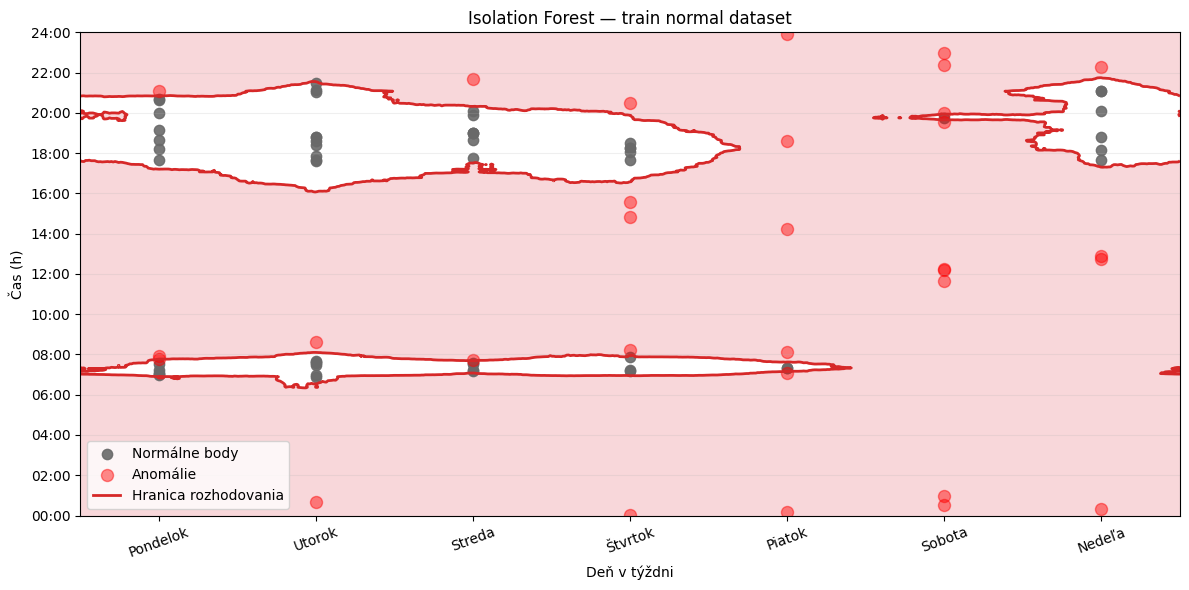

In [131]:
model_if = models["Isolation Forest"]["model"]

pred = model_if.predict(X_train)

xx, yy = np.meshgrid(
    np.linspace(-0.5, 6.5, 600),
    np.linspace(0, 24, 600)
)

grid_features = pd.DataFrame({
    'time_sin': np.sin(2 * np.pi * (yy.ravel() / 24)),
    'time_cos': np.cos(2 * np.pi * (yy.ravel() / 24)),
    'day_sin': np.sin(2 * np.pi * (xx.ravel() / 7)),
    'day_cos': np.cos(2 * np.pi * (xx.ravel() / 7)),
})

zz = model_if.decision_function(grid_features[features]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(12, 6))

ax.contourf(
    xx, yy, zz,
    levels=[zz.min(), 0, zz.max()],
    colors=['#f8d7da', '#ffffff'],
    alpha=1.0
)

ax.contour(
    xx, yy, zz,
    levels=[0],
    colors=['#d62828'],
    linewidths=2
)

normal_mask = pred == 1
anomaly_mask = pred == -1

ax.scatter(
    train_normal.loc[normal_mask, 'day_of_week'],
    train_normal.loc[normal_mask, 'time_of_day_seconds'] / 3600,
    color='dimgray',
    alpha=0.9,
    s=55,
    label='Normal points'
)

ax.scatter(
    train_normal.loc[anomaly_mask, 'day_of_week'],
    train_normal.loc[anomaly_mask, 'time_of_day_seconds'] / 3600,
    color='red',
    alpha=0.45,
    s=75,
    label='Anomalies'
)

ax.plot([], [], color='#d62828', linewidth=2, label='Decision boundary')

ax.set_xticks(range(7))
ax.set_xticklabels(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], rotation=20)
ax.set_xlabel('Day of week')
ax.set_ylabel('Time (h)')
ax.set_title('Isolation Forest — train normal dataset')
ax.set_ylim(0, 24)
ax.set_yticks(range(0, 25, 2))
ax.set_yticklabels([f'{h:02d}:00' for h in range(0, 25, 2)])
ax.grid(axis='y', alpha=0.2)
ax.legend()

plt.tight_layout()
plt.show()


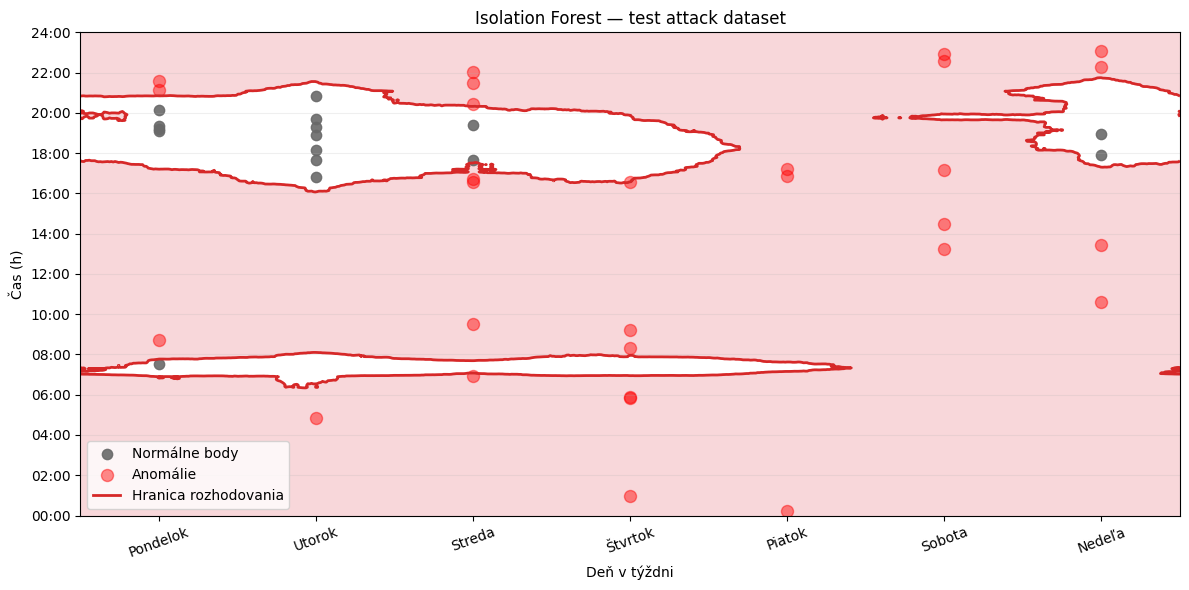

In [134]:
model_if = models["Isolation Forest"]["model"]

pred = model_if.predict(X_test_attack)

xx, yy = np.meshgrid(
    np.linspace(-0.5, 6.5, 600),
    np.linspace(0, 24, 600)
)

grid_features = pd.DataFrame({
    'time_sin': np.sin(2 * np.pi * (yy.ravel() / 24)),
    'time_cos': np.cos(2 * np.pi * (yy.ravel() / 24)),
    'day_sin': np.sin(2 * np.pi * (xx.ravel() / 7)),
    'day_cos': np.cos(2 * np.pi * (xx.ravel() / 7)),
})

zz = model_if.decision_function(grid_features[features]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(12, 6))

ax.contourf(
    xx, yy, zz,
    levels=[zz.min(), 0, zz.max()],
    colors=['#f8d7da', '#ffffff'],
    alpha=1.0
)

ax.contour(
    xx, yy, zz,
    levels=[0],
    colors=['#d62828'],
    linewidths=2
)

normal_mask = pred == 1
anomaly_mask = pred == -1

ax.scatter(
    test_attack.loc[normal_mask, 'day_of_week'],
    test_attack.loc[normal_mask, 'time_of_day_seconds'] / 3600,
    color='dimgray',
    alpha=0.9,
    s=55,
    label='Normal points'
)

ax.scatter(
    test_attack.loc[anomaly_mask, 'day_of_week'],
    test_attack.loc[anomaly_mask, 'time_of_day_seconds'] / 3600,
    color='red',
    alpha=0.45,
    s=75,
    label='Anomalies'
)

ax.plot([], [], color='#d62828', linewidth=2, label='Decision boundary')

ax.set_xticks(range(7))
ax.set_xticklabels(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], rotation=20)
ax.set_xlabel('Day of week')
ax.set_ylabel('Time (h)')
ax.set_title('Isolation Forest — attack dataset')
ax.set_ylim(0, 24)
ax.set_yticks(range(0, 25, 2))
ax.set_yticklabels([f'{h:02d}:00' for h in range(0, 25, 2)])
ax.grid(axis='y', alpha=0.2)
ax.legend()

plt.tight_layout()
plt.show()


### Tap Duration and Speed

One advantage of machine learning is the ability to work with a large number of features. We now add features describing the approach behaviour from the ToF sensor and re-run the comparison.


In [154]:
contamination = 0.09
random_state = 82
n_estimators = 200
n_neighbors = min(20, len(train_normal) - 1)


In [ ]:
features = [
    'time_sin', 'time_cos','day_sin', 'day_cos','rfid_hold_duration_ms','tof_len','tof_start','tof_end','tof_min','tof_max','tof_mean','tof_std','tof_range','tof_approach_distance','tof_approach_speed'
]

X_train = train_normal[features].copy()
X_test_normal = test_normal[features].copy()
X_test_attack = test_attack[features].copy()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_normal_scaled = scaler.transform(X_test_normal)
X_test_attack_scaled = scaler.transform(X_test_attack)

models = {
    "Isolation Forest": {
        "model": IsolationForest(
            n_estimators=n_estimators,
            contamination=contamination,
            random_state=random_state
        ),
        "X_train": X_train,
        "X_test_normal": X_test_normal,
        "X_test_attack": X_test_attack
    },
    "One-Class SVM": {
        "model": OneClassSVM(
            kernel="rbf",
            nu=contamination,
            gamma="scale"
        ),
        "X_train": X_train_scaled,
        "X_test_normal": X_test_normal_scaled,
        "X_test_attack": X_test_attack_scaled
    },
    "Local Outlier Factor": {
        "model": LocalOutlierFactor(
            n_neighbors=n_neighbors,
            contamination=contamination,
            novelty=True
        ),
        "X_train": X_train_scaled,
        "X_test_normal": X_test_normal_scaled,
        "X_test_attack": X_test_attack_scaled
    },
    "Elliptic Envelope": {
        "model": EllipticEnvelope(
            contamination=contamination,
            random_state=random_state
        ),
        "X_train": X_train_scaled,
        "X_test_normal": X_test_normal_scaled,
        "X_test_attack": X_test_attack_scaled
    }
}

rows = []

for name, cfg in models.items():
    model = cfg["model"]
    model.fit(cfg["X_train"])

    pred_normal = model.predict(cfg["X_test_normal"])
    pred_attack = model.predict(cfg["X_test_attack"])

    false_rejections = int((pred_normal == -1).sum())
    false_acceptances = int((pred_attack == 1).sum())

    frr = false_rejections / len(test_normal) * 100
    far = false_acceptances / len(test_attack) * 100

    rows.append({
        "Algorithm": name,
        "FRR (%)": round(frr, 2),
        "FAR (%)": round(far, 2),
        "False Rejections": false_rejections,
        "False Acceptances": false_acceptances
    })

results = pd.DataFrame(rows).sort_values(["FAR (%)", "FRR (%)"]).reset_index(drop=True)
results


c:\Users\Ján\Documents\Škola\SkV\.venv\Lib\site-packages\sklearn\covariance\_robust_covariance.py:793: UserWarning: The covariance matrix associated to your dataset is not full rank
  warnings.warn(
c:\Users\Ján\Documents\Škola\SkV\.venv\Lib\site-packages\sklearn\covariance\_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-134.198687613344333 > -159.490846294910739). You may want to try with a higher value of support_fraction (current value: 0.598).
  warnings.warn(
c:\Users\Ján\Documents\Škola\SkV\.venv\Lib\site-packages\sklearn\covariance\_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-130.586288224953364 > -132.006429178289864). You may want to try with a higher value of support_fraction (current value: 0.598).
  warnings.warn(
c:\Users\Ján\Documents\Škola\SkV\.venv\Lib\site-packages\sklearn\covariance\_robust_covariance.py:188: Runt

,Algorithm,FRR (%),FAR (%),False Rejections,False Acceptances
0,Elliptic Envelope,7.89,0.00,3,0
1,One-Class SVM,23.68,2.22,9,1
2,Local Outlier Factor,10.53,13.33,4,6
3,Isolation Forest,13.16,26.67,5,12


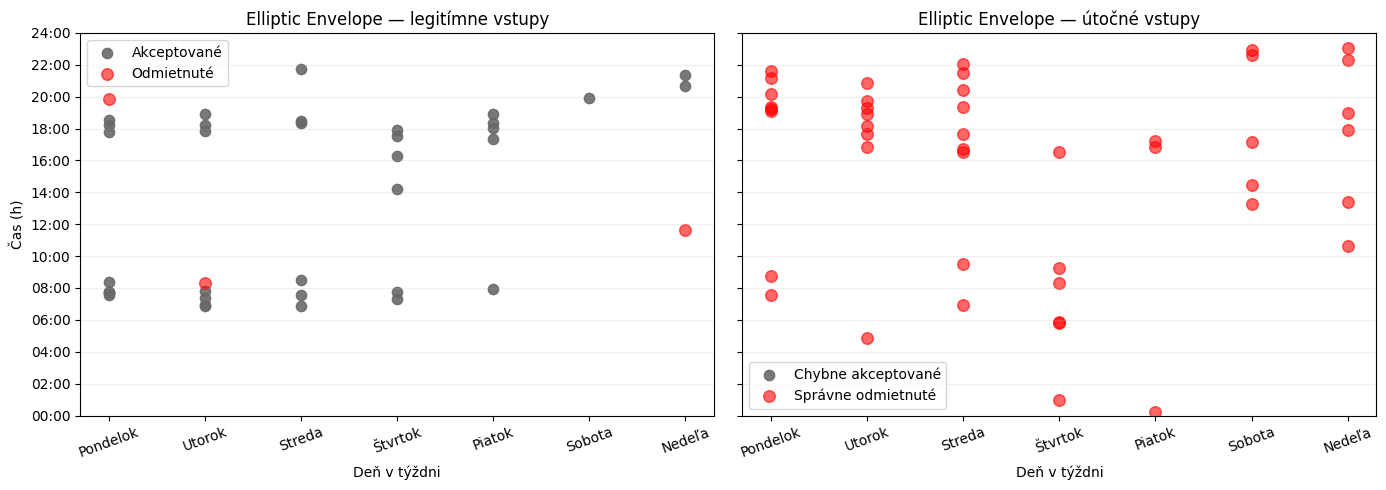

In [165]:
model_ee = models["Elliptic Envelope"]["model"]

pred_test_normal = model_ee.predict(X_test_normal_scaled)
pred_test_attack = model_ee.predict(X_test_attack_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

day_labels = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# TEST NORMAL
ok_mask = pred_test_normal == 1
rej_mask = pred_test_normal == -1

axes[0].scatter(
    test_normal.loc[ok_mask, 'day_of_week'],
    test_normal.loc[ok_mask, 'time_of_day_seconds'] / 3600,
    color='dimgray',
    s=55,
    alpha=0.9,
    label='Accepted'
)

axes[0].scatter(
    test_normal.loc[rej_mask, 'day_of_week'],
    test_normal.loc[rej_mask, 'time_of_day_seconds'] / 3600,
    color='red',
    s=70,
    alpha=0.6,
    label='Rejected'
)

axes[0].set_title('Elliptic Envelope — legitimate entries')
axes[0].set_xlabel('Day of week')
axes[0].set_ylabel('Time (h)')
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(day_labels, rotation=20)
axes[0].set_ylim(0, 24)
axes[0].set_yticks(range(0, 25, 2))
axes[0].set_yticklabels([f'{h:02d}:00' for h in range(0, 25, 2)])
axes[0].grid(axis='y', alpha=0.2)
axes[0].legend()

# TEST ATTACK
ok_mask = pred_test_attack == 1
rej_mask = pred_test_attack == -1

axes[1].scatter(
    test_attack.loc[ok_mask, 'day_of_week'],
    test_attack.loc[ok_mask, 'time_of_day_seconds'] / 3600,
    color='dimgray',
    s=55,
    alpha=0.9,
    label='Falsely accepted'
)

axes[1].scatter(
    test_attack.loc[rej_mask, 'day_of_week'],
    test_attack.loc[rej_mask, 'time_of_day_seconds'] / 3600,
    color='red',
    s=70,
    alpha=0.6,
    label='Correctly rejected'
)

axes[1].set_title('Elliptic Envelope — attack entries')
axes[1].set_xlabel('Day of week')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(day_labels, rotation=20)
axes[1].set_ylim(0, 24)
axes[1].set_yticks(range(0, 25, 2))
axes[1].set_yticklabels([f'{h:02d}:00' for h in range(0, 25, 2)])
axes[1].grid(axis='y', alpha=0.2)
axes[1].legend()

plt.tight_layout()
plt.show()


In [164]:
# data
X_train = train_normal[features].copy()
X_test_normal = test_normal[features].copy()
X_test_attack = test_attack[features].copy()

# scaling
scaler_nn = StandardScaler()
X_train_scaled = scaler_nn.fit_transform(X_train)
X_test_normal_scaled = scaler_nn.transform(X_test_normal)
X_test_attack_scaled = scaler_nn.transform(X_test_attack)

# autoencoder-like neural network
nn = MLPRegressor(
    hidden_layer_sizes=(12, 6, 12),
    activation='relu',
    solver='adam',
    max_iter=20000,
    random_state=8020
)

# train to reconstruct normal data
nn.fit(X_train_scaled, X_train_scaled)

# reconstruction error
train_recon = nn.predict(X_train_scaled)
test_normal_recon = nn.predict(X_test_normal_scaled)
test_attack_recon = nn.predict(X_test_attack_scaled)

train_err = np.mean((X_train_scaled - train_recon) ** 2, axis=1)
test_normal_err = np.mean((X_test_normal_scaled - test_normal_recon) ** 2, axis=1)
test_attack_err = np.mean((X_test_attack_scaled - test_attack_recon) ** 2, axis=1)

# threshold from training data (95th percentile)
threshold = np.percentile(train_err, 95)

# predictions
pred_test_normal = np.where(test_normal_err > threshold, -1, 1)
pred_test_attack = np.where(test_attack_err > threshold, -1, 1)

# metrics
false_rejections = (pred_test_normal == -1).sum()
false_acceptances = (pred_test_attack == 1).sum()

frr = false_rejections / len(test_normal) * 100
far = false_acceptances / len(test_attack) * 100

print("=== Neural Network (autoencoder) ===")
print(f"Threshold: {threshold:.4f}")
print(f"FRR: {frr:.2f}% ({false_rejections}/{len(test_normal)})")
print(f"FAR: {far:.2f}% ({false_acceptances}/{len(test_attack)})")


=== Neural Network (autoencoder) ===
Threshold: 0.3416
FRR: 2.63% (1/38)
FAR: 4.44% (2/45)
